<a href="https://colab.research.google.com/github/Valeriy1990/Else/blob/main/21_1_%D0%A0%D0%B5%D0%BA%D1%83%D1%80%D1%80%D0%B5%D0%BD%D1%82%D0%BD%D1%8B%D0%B5_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

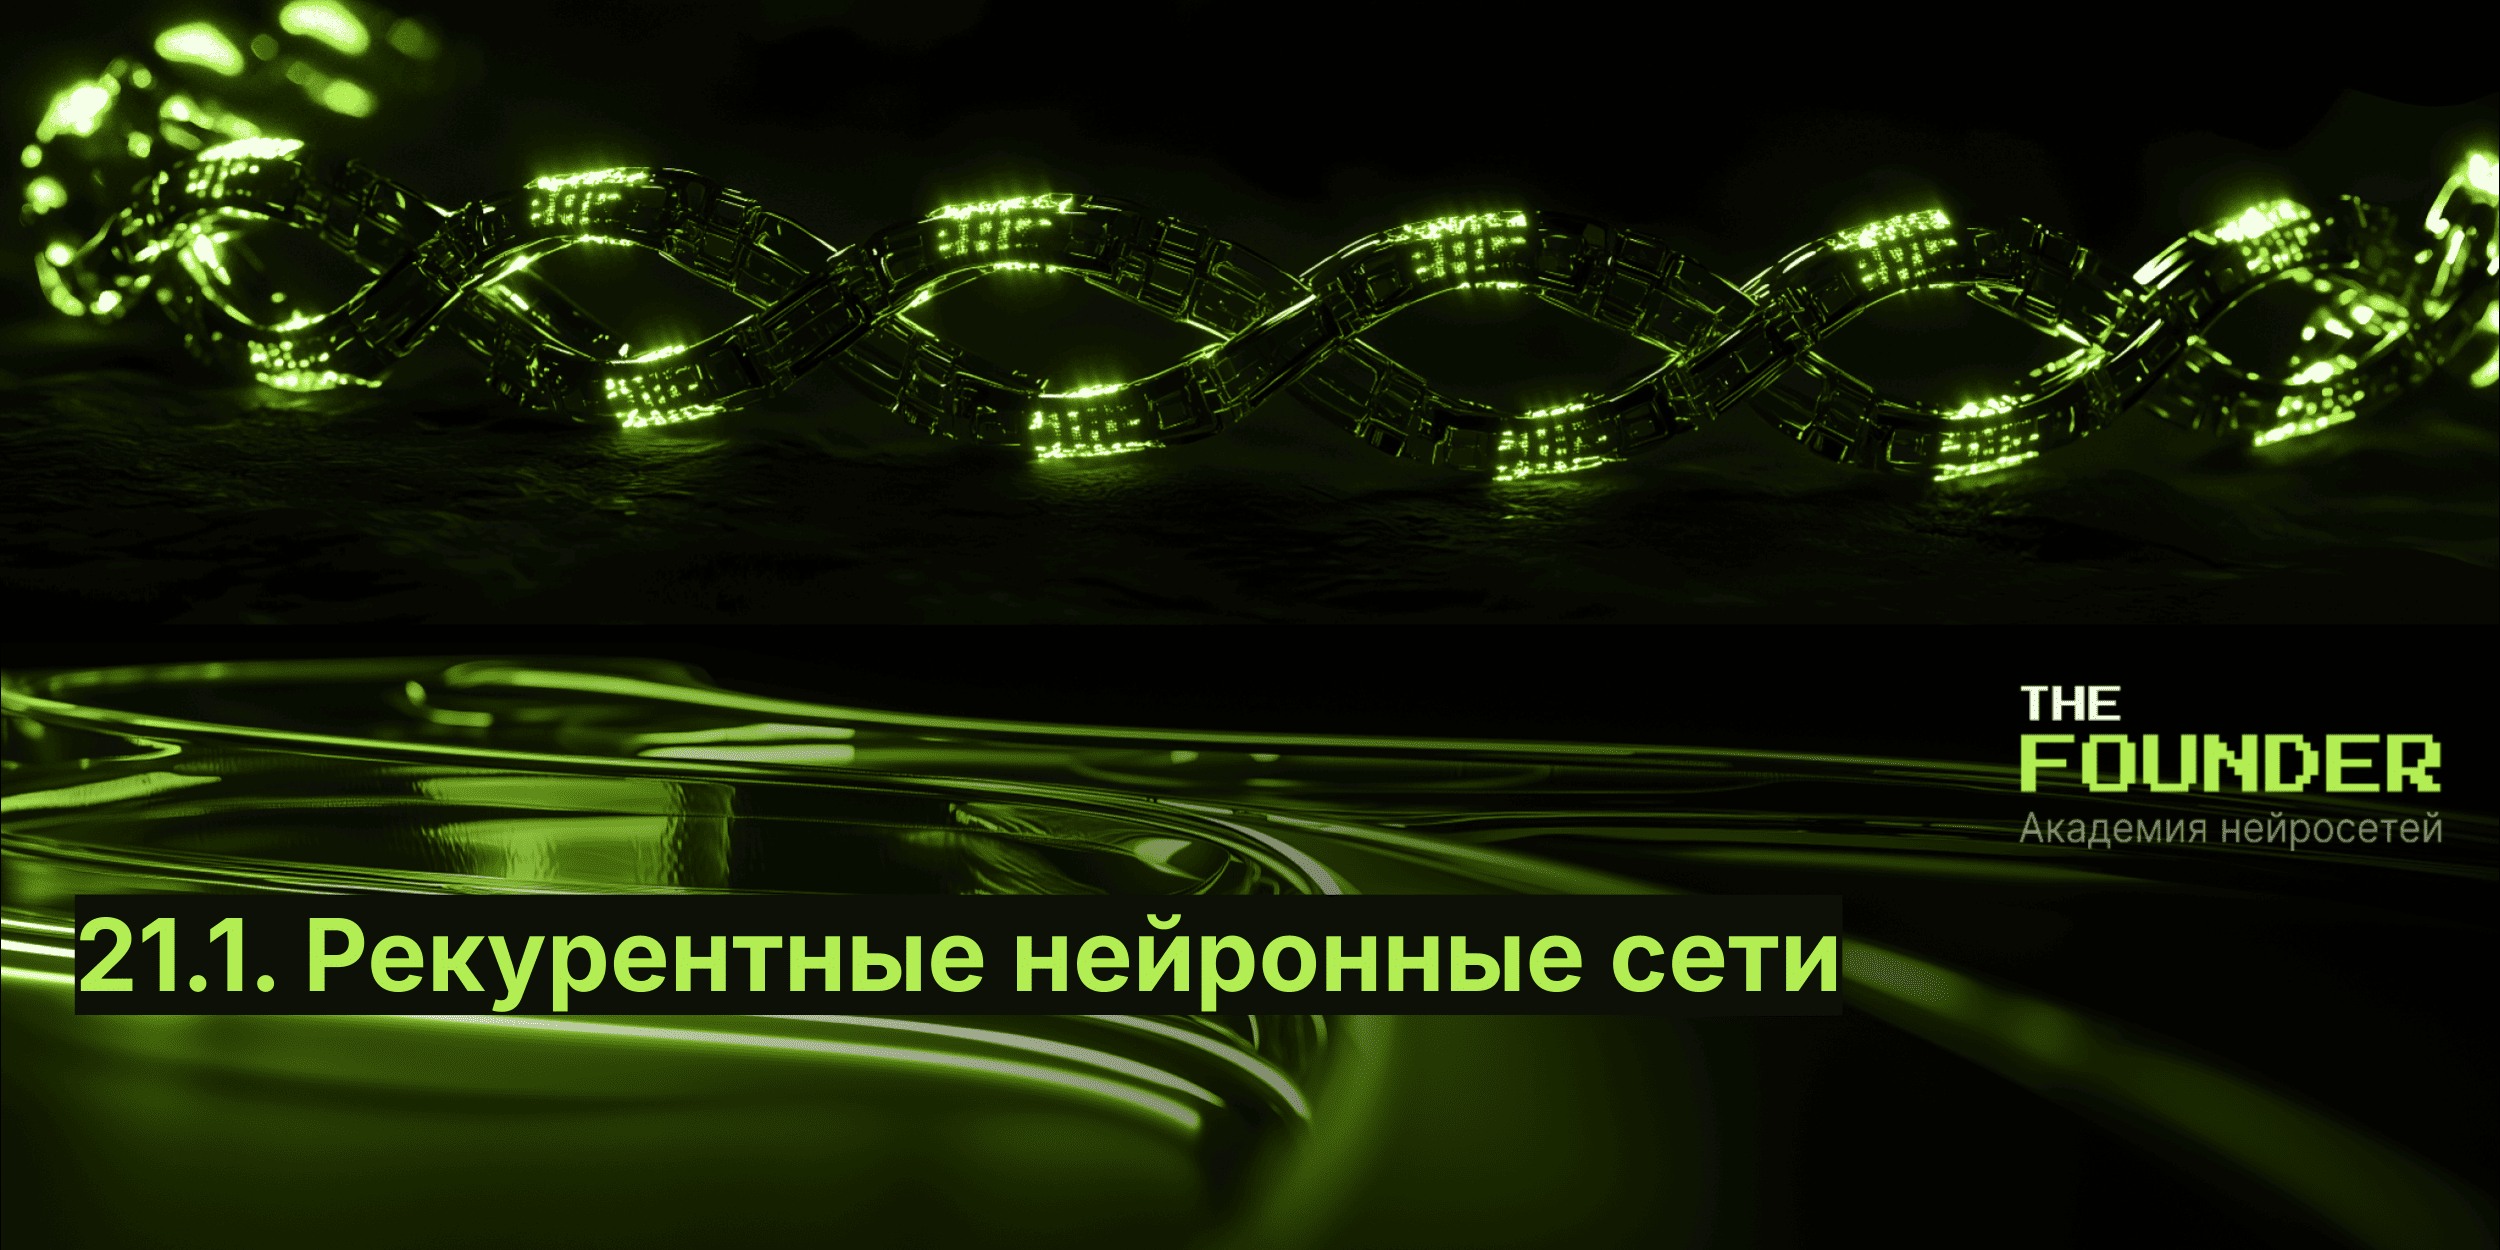

**Навигация по уроку**

1. Рекуррентные нейронные сети
2. [Одномерные сверточные нейронные сети](https://colab.research.google.com/drive/1SCmcJdfsaxpJiQz_SOMH6gixV-43zPIB)
3. [Сравнение архитектур рекуррентных и одномерных сверточных сетей](https://colab.research.google.com/drive/15-SEqMwU3ALZmiEtlJFZllc38VTGHkGu)
4. [Домашняя работа](https://colab.research.google.com/drive/1NMDG3ZeGgyHm0ei0DOC63PBb9rW6oN3O)

В этом уроке мы рассмотрим, как глубокое обучение может справляться
с задачами потоковой информации.

Если изображение представляет собой статический моментальный снимок, видео, состоящее из последовательности связанных изображений, является потоком информации, и фильм может рассказать вам гораздо больше, чем отдельная фотография или серия фотографий.

Поток изображений, текстовые данные, числовые ряды, все то что можно представить на временной шкале - все это интересует нас в рамках урока.    

В этом уроке мы изучим ряд новых слоев, а именно, рекуррентные сети (RNN или РНС) и все их модификации, такие как слои LSTM и GRU.

Эти технологии лежат в основе самых удивительных приложений глубокого обучения, с которыми мы встречаемся каждый день: беря мобильный телефон в руки, включая умный телевизор или колонку, используя компоненты умного дома. Например, подобные сети реализованы в умных помощниках таких, как Siri, Google Ноте или Alexa. Другое приложение технологии, - Google Translate, - переводит вашу речь на другой язык.

За каждой из этих технологий стоит особая нейронная архитектура, а для их обучения используются специфические для данной области данные - некоторые из них общедоступны, а некоторые нет. Даже с учетом этих различий в источнике данных и методике, слои, делающие все это возможным, являются точно теми же слоями, которые вы импортируете из TensorFlow и Keras, и которые используете в коде своих приложений.

## Рекуррентные нейронные сети

Первые РНС (рекуррентные нейронные сети) были предложены в 1980-е годы, но популярность обрели лишь недавно, благодаря нескольким интеллектуальным и техническим прорывам, которые помогли повысить их обучаемость.
Главной характеристикой всех нейронных сетей, с которыми мы уже познакомились, такими как полносвязные и сверточные нейронные сети, является отсутствие памяти. Каждый вход обрабатывается ими независимо, без сохранения состояния между ними. Чтобы с помощью таких сетей обработать последовательность или временной ряд данных, необходимо передать в сеть всю последовательность целиком, преобразовав ее в единый пакет. Такие сети называют сетями прямого
распространения.

РНС отличаются от сетей с прямым распространением сигнала тем, что в них используется особый тип нейронного слоя, именуемый рекуррентным, и позволяющий сети сохранять свое состояние в промежутках между сеансами ее использования.

Если сравнить нейронную сеть с мозгом, то становиться очевидно, что мозг обрабатываем информацию постепенно, малыми порциями, постояно запоминая предыдущую информацию. Тем самым, наш с вами мозг работает по алгоритму, который больше напоминает рекуррентную сеть, чем сети прямого распространения.

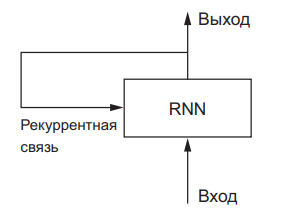

Рис. 1. Схематическое представление рекуррентной сети

Рекуррентная нейронная сеть (RNN) использует тот же принцип, что и мозг, хотя и в чрезвычайно упрощенном виде. Сеть обрабатывает последовательность, перебирая ее элементы и сохраняя состояние, полученное при обработке предыдущих элементов. RNN — это разновидность нейронной сети, имеющей внутренний цикл и рекуррентную связь для передачи состояния, что схематически показано на рис. 1. Однако в таком представлении не расскрывается суть RNN.




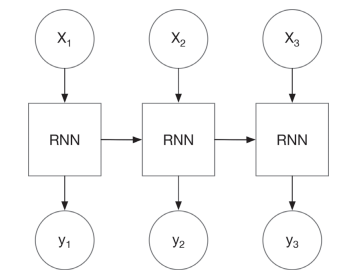

Рис. 2. Развернутое представление рекуррентной сети

Элементы последовательности подаются на вход сети по одному.
А затем сеть делает нечто необычное. На следующем шаге выход из каждого слоя
возвращается на свой собственный вход! Это позволяет RNN иметь своего рода
память.

Таким образом, вход для рекуррентного слоя состоит из двух частей: обычного
входа (то есть выход предыдущего слоя) и повторного входа (который равен его собственному выходу на предыдущем шаге). Далее происходит расчет нового результата на основе этих входных данных (см. рис. 2).

Для моделирования подобной сети можно обойтись только полносвязанными слоями. Но на практике такой подход плохо работает. Исследователями были разработаны специализированные типы слоев, которые работают в RNN намного лучше. Наиболее популярны: управляемый рекуррентный блок (gated-recurrent unit, GRU) и долгая краткосрочная память (long short-term memory, LSTM).

При создании рекуррентной нейросети вы будете использовать один из этих двух типов слоев.

Наличие памяти принципиально отличает RNN от других моделей, которые мы
обсуждали. Например, в сверточных сетях, мы просто подавали данные на вход сети и получали значения на выходе. Вывод полностью определяется текущим вводом.

RNN работает иначе. Модель имеет собственное «внутреннее состояние» – выходы всех слоев на самом последнем шаге. Каждый раз, когда мы вводим в модель новое значение, выход зависит не только от входного значения, но и от внутреннего состояния. Аналогично, внутреннее состояние изменяется с каждым новым
входным значением. Это свойство делает рекуррентные нейросети очень мощными и позволяет использовать их для множества различных приложений.

> **Вот как Юрген Шмидхубер (широко известный в узких кругах нейронщик-исследователь) объясняет принцип работы РНС:**
Рекуррентные нейронные сети позволяют производить как параллельные, так
и последовательные вычисления и в принципе способны вычислить все, что может
вычислить традиционный компьютер. Но, в отличие от традиционных компьютеров, рекуррентные нейронные сети напоминают человеческий мозг, представляющий собой большую сеть взаимосвязанных нейронов с обратной связью, которая каким-то образом обучается транслировать входной поток чувственных ощущений, полученных на протяжении всей жизни, в последовательность полезных моторных реакций. Мозг – потрясающий образец для подражания, поскольку он умеет решать задачи, недоступные современным машинам.



Чтобы пояснить понятия «цикл» и «состояние», реализуем средствами Numpy простую сеть RNN, изображенную на рис. 3.

Она будет принимать на входе последовательность векторов в виде двумерного тензора с формой `(временные интервалы, входные признаки)`, перебирать временные интервалы и, учитывая текущее состояние
и входные признаки (с формой `(входные_признаки,)`) в момент $t$, конструировать
выходной результат, соответствующий моменту $t$.

Этот результат затем будет сохраняться во внутреннем состоянии как подготовка к следующей итерации. Эти состояния принято называть "скрытыми состояниями".

Для первого временного интервала предыдущий выходной результат не определен и сеть не имеет текущего состояния. Поэтому текущее состояние первоначально инициализируется вектором с нулевыми значениями элементов, который называют начальным состоянием сети.



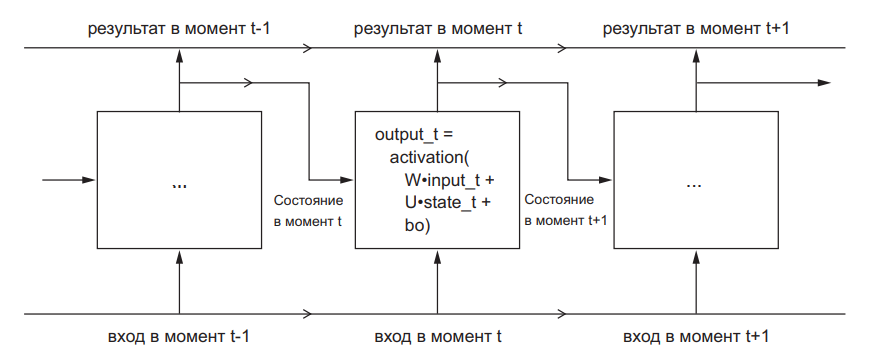

Рис. 3. Простая рекуррентная сеть (развернутая во времени)

In [ ]:
import numpy as np

timesteps = 100                                                     # Число временных интервалов во входной последовательности
input_features = 32                                                 # Размерность пространства входных признаков
output_features = 64                                                # Размерность пространства выходных признаков
inputs = np.random.random((timesteps, input_features))              # Входные данные: случайный шум для простоты примера
state_t = np.zeros((output_features,))                              # Начальное состояние: вектор с нулевыми значениями элементов

# Создание матриц со случайными весами
W = np.random.random((output_features, input_features))             # Инициализируем матрицу входных весов
U = np.random.random((output_features, output_features))            # Инициализируем матрицу состояний
b = np.random.random((output_features,))                            # Инициализируем матрицу смещений

successive_outputs = []

for input_t in inputs:                                              # input_t — вектор с формой (входные_признаки,)
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b) # Объединение входных данных с текущим состоянием (выходными данными на предыдущем шаге)
    successive_outputs.append(output_t)                             # Сохранение выходных данных в список
    state_t = output_t                                              # Обновление текущего состояния сети как подготовка к обработке следующего временного интервала

final_output_sequence = np.concatenate(successive_outputs, axis=0)  # Окончательный результат — двумерный тензор с формой (временные интервалы, выходные признаки)

Очевидно, что RNN — это просто цикл `for`, который повторно использует
величины, вычисленные в предыдущей итерации. Подобным образом можно сконструировать множество разных сетей RNN, соответствующих этому определению, и этот пример — одна из простейших реализаций RNN. Рекуррентные сети характеризуются функцией, которая выполняется на каждом шагу. В нашем случае эта функция:

```python
output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)
```


В нашем примере конечный результат имеет вид двумерного тензора с формой `(временные интервалы, выходные признаки)`, где каждый временной интервал — это результат цикла в момент времени $t$.

Каждому временному интервалу $t$ в выходном тензоре соответствует информация о временных интервалах от $0$ до $t$ во входной последовательности, т.е. о всем прошлом. Поэтому во многих случаях нет необходимости иметь всю последовательность результатов, а достаточно получить последний результат (значение `output_t` по окончании цикла), так как он уже содержит информацию обо всей последовательности.

Процессу, который мы только что реализовали с применением Numpy, соответствует слою `SimpleRNN` в Keras:

```python
from keras.layers import SimpleRNN
```

С одним незначительным отличием: `SimpleRNN` обрабатывает пакеты последовательностей, как и все другие слои в Keras, а не единственную последовательность, как наш предыдущий пример.

Это означает, что он принимает входные данные с формой `(размер пакета, временные интервалы, входные признаки)`, а не `(временные интервалы, входные признаки)`.

Подобно всем рекуррентным слоям в Keras, `SimpleRNN` может действовать в двух
разных режимах:
* возвращать полные последовательности результатов для всех временных интервалов - трехмерный тензор с формой `(размер_пакета,временные_интервалы, выходные_признаки)`
* возвращать только последний результат для каждой входной последовательности - двумерный тензор с формой `(размер пакета,
выходные признаки)`

Выбор режима управляется аргументом `return_sequences` (`True` - возвращать последовательность, `False` - только результат) конструктора.

## Проблема исчезающего (затухающего) градиента

Слой `SimpleRNN` страдает одной существенной проблемой. Теоретически в каждый момент времени $t$ он должен хранить информацию о входных данных за многочисленные предыдущие интервалы времени, но на практике такие протяженные зависимости не поддаются обучению.

Это связано с проблемой исчезающего градиента, напоминающего эффект, который наблюдается в нерекуррентных сетях (сетях прямого распространения) с большим количеством слоев. Когда по мере увеличения количества слоев сеть в конечном итоге становится необучаемой.

> **Градиент - это тот вектор, который мы используем для обновления весовых коэффициентов сети, чтобы она могла работать лучше в будущем.**

Из-за обратного распространения и правила цепочки, когда обновление градиента невелико, оно экспоненциально уменьшается с увеличением количества слоев. Следовательно, в очень глубоких архитектурах с большим количеством уровней обновление, происходящее на очень глубоком уровне, не оказывает никакого влияния на передние уровни (оно исчезает), и сеть не может учиться.




На рисунке ниже мы видим RNN, где начальные обновления экспоненциально теряют силу по мере прохождения последовательности:

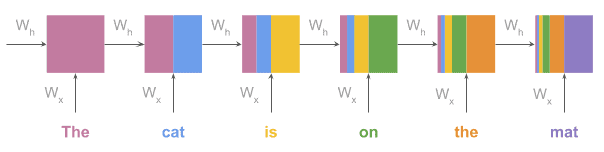

Рис. 4. Затухание градиентов в RNN ($W_h$ - матрица состояний, $W_x$ - матрица входных весов)


В глубоких нейронных сетях градиенты служат индикаторами корректировки веса, чтобы минимизировать разрыв между прогнозируемыми и фактическими результатами. Тем не менее, они часто становятся слабее по мере прохождения слоев, потенциально вызывая замедление или даже остановку обучения на начальных уровнях.

Это явление называется проблемой исчезающего градиента. Эта проблема становится более заметной в глубоких архитектурах и сетях, использующих функции активации, которые искажают входные значения.

В контексте `SimpleRNN` проблема исчезающего градиента возникает из-за повторяющихся соединений и распространения градиентов с разными временными шагами.

На каждом временном шаге $t$ ячейка `SimpleRNN` принимает как текущий ввод, так и скрытое состояние из предыдущего временного шага, чтобы вычислить новое скрытое состояние и выдать результат.

Скрытое состояние на временном шаге $t-1$ влияет на скрытое состояние на временном шаге $t$. Эта зависимость от предыдущих временных шагов вызывает распространение градиента по цепочке повторяющихся соединений.

В процессе обратного распространения во времени мы вычисляем градиенты, итеративно используя правило цепочки на различных временных этапах. Этот итерационный процесс начинается с последнего временного шага `T` и продолжается в обратном порядке.

Проблема исчезающего градиента в `SimpleRNN` возникает из-за того, что градиенты распространяясь в обратном направлении во времени, могут стать очень маленькими, ведь они притерпевают многократное перемножение на каждом временном шаге. В результате более ранние временные шаги в последовательности получают очень слабые сигналы градиента во время обучения, поэтому их веса обновляются медленно или не обновляются вообще. Это приводит к потере важной информации и замедлению процесса обучения.

Поэтому для ячейки `SimpleRNN` очень важна "правильная" инициализация весов (при малых весах градиент быстрее затухнет).

> SimpleRNN не единственный рекуррентный слой, доступный в Keras. Кроме него
имеются также слои LSTM и GRU. В практических решениях они используются чаще,
потому что SimpleRNN слишком прост для реальных задач.

## Слои LSTM и GRU

Слои LSTM и GRU создавались специально для решения проблемы с затуханием градиента.

### LSTM

Рассмотрим слой LSTM. Лежащий в его основе алгоритм долгой краткосрочной памяти (Long Short-Term Memory, LSTM) был разработан Хохрейтером и Шмидхубером в 1997 году, занимавшими проблемами затухания градиента.

Этот слой является вариантом слоя SimpleRNN. Он добавляет поддержку переноса информации через многие интервалы времени. Представьте себе конвеерную ленту, движущуюся параллельно обрабатываемой последовательности. Информация из последовательности может в любой момент перекладываться на конвейерную ленту, переноситься к более поздним интервалам времени и сниматься с ленты, если она необходима.

Чтобы лучше представить аналогию изобразим ячейку `SimpleRNN` в упрощенном виде (см. рис. 5) и переименуем входные, выходные векторы, а также векторы состояний в терминах и обозначениях LSTM.





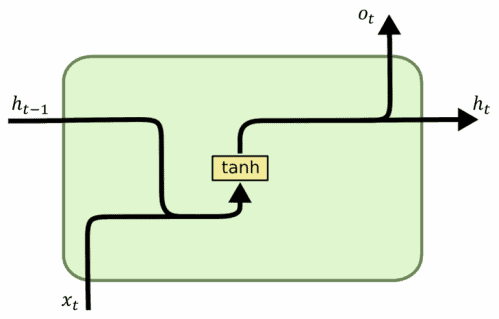


      
**Входные данные:** $h_{t-1}$ - предыдущее состояние последовательности, $x_t$ - вектор слов для текущего состояния.

**Вывод:** $h_t$ - текущее состояние, которое будет передано следующему блоку, и $o_t$ выходной вектор.

Рис. 5. Простая рекурентная сеть (схематическое изображение)

Блок долговременной кратковременной памяти (LSTM), представленный на рис. 6 состоит из ячейки, элемента ввода, элемента вывода и элемента забывания.



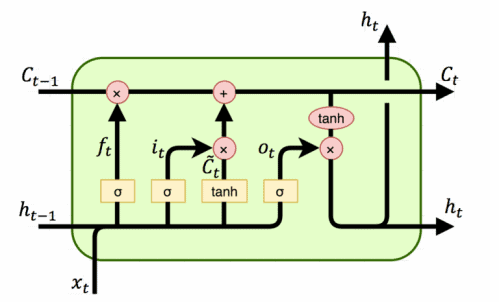

Рис. 6. Схематическое изображение LSTM

Начальной точкой слоя LSTM является слой SimpleRNN. Добавим в него дополнительный поток данных, несущий информацию сквозь интервалы времени. Для его значений в разные интервалы времени будем использовать обозначение $C_t$.

Поток переноса $C_{t-1}$ будет оказывать следующее влияние на ячейку:
* объединяться с входящей и рекуррентной связями путем плотного преобразования (скалярное произведение на весовую матрицу с добавлением смещения и применением функции активации)
* оказывать влияние на состояние, передаваемое в следующий интервал времени (через функцию активации и операцию умножения).

**Концептуально, поток переноса информации осуществляет модулирование следующего результата и следующего состояния**.

**В LSTM включены три элемента:** элемент ввода, элемент забывания и элемент вывода. Эти вентили (или ворота) управляют потоком информации через ячейку LSTM, позволяя ей решать, что запомнить, что забыть и что вывести. Более того, эти вентили позволяют LSTM управлять потоком градиентов во времени, эффективно решая проблему исчезающего градиента.


**Вентиль забывания $f_t$:**  

Элемент забывания решает, какую информацию следует забыть из предыдущего скрытого состояния $h_{t-1}$ и текущего ввода $x_t$. Используя функцию активации сигмовидной формы, он выдает значения от 0 до 1, в идеале указывающие долю данных, которые проходят через состояние ячейки.

Кроме того, элемент забывания позволяет LSTM сохранять важные данные и избавляться от ненужных, гарантируя, что градиенты остаются актуальными. Это позволяет LSTM обрабатывать гораздо более длинные последовательности данных, чем это возможно для стандартных RNN.

**Вентили ввода $i_t$ и вывода $o_t$:**  

В отличие от элемента забывания $f_t$, элемент ввода $i_t$ определяет, какие новые детали следует добавить в состояние ячейки. Он состоит из двух частей: функции активации сигмоида, которая выбирает значения для обновления ячейки, и функции активации `tanh`, которая выдает новые значения-кандидаты для состояния ячейки.

Между тем, элемент управления выводом $o_t$ определяет, какие данные должны быть представлены в качестве текущих выходных данных ячейки LSTM $h_t$. Он обрабатывает обновленное состояние ячейки и текущее скрытое состояние для получения выходных данных $h_t$. Элемент вывода обеспечивает значимые результаты за счет уточнения данных внутри состояния ячейки. Эти элементы управления имеют решающее значение для точного определения необходимых данных для данной задачи, сохранения важной информации в расширенных последовательностях и, таким образом, решения проблемы исчезающего градиента.

Входные и выходные элементы управления умножают свои результаты на другие факторы. Их природа гарантирует, что если выходное значение близко к 1, градиенты проходят беспрепятственно, но если оно около 0, поток останавливается. Эти элементы управления помогают выбирать, какие данные необходимы для текущей задачи. Следовательно, они помогают сохранять только важную информацию в более длинных последовательностях, что устраняет проблему исчезающего градиента.

Объединение результатов входного элемента $x_t$ и предыдущего состояния ячейки $h_{t-1}$ уточняет состояние ячейки на текущем временном шаге. Это состояние ячейки памяти хранит данные на различных временных шагах, позволяя сети фиксировать зависимости на более дальних расстояниях. Благодаря механизму аддитивного обновления ячейка памяти LSTM обеспечивает постоянство градиентов на протяжении длинных последовательностей.

Благодаря этим механизмам управления LSTM лучше справляются с проблемой исчезающего градиента. Они превосходно справляются с задачами, понимая долгосрочные последовательности и зависимости.

В этом и заключается суть работы слоя LSTM: он сохраняет информацию для последующего использования, тем самым предотвращая постепенное затухание старых сигналов во время обработки.

### Ограничения LSTM

Хотя сети с долговременной кратковременной памятью (LSTM) эффективно решают проблему исчезающего градиента и распознают долгосрочные шаблоны в последовательностях, у них есть свой набор проблем:

**Взрыв градиента**
Взрыв градиента происходит, когда градиенты становятся чрезвычайно большими во время обратного распространения, особенно при очень длинной последовательности ввода или инициализации сети с большими весами.

**Ограничение контекста**
При обработке чрезвычайно длинных последовательностей LSTM может испытывать трудности с запоминанием более ранней информации и заменой старых данных новыми входными данными. Это происходит, когда элемент забывания становится чрезмерно доминирующим.

**Сложность обучения**
LSTM с их вентильными механизмами и множеством компонентов сложнее, чем SimpleRNN. В результате они обладают параметрами, примерно в четыре раза превышающими параметры базовой RNN. Эта сложность может привести к увеличению времени обучения и потребовать более тщательной настройки гиперпараметров. Кроме того, обучение глубоких сетей LSTM остается сложной задачей из-за исчезающих градиентов в очень глубоких архитектурах.

**Чувствительность к конфигурации**
Производительность LSTM зависит от точной конфигурации его вентильного механизма. Неправильные настройки весов элементов или неправильно выбранные гиперпараметры могут снизить эффективность обучения модели, что приведет к проблемам, связанным с градиентом.

**Адаптация к задаче**
Степень, в которой LSTM может решить проблему исчезающего градиента и выявить долгосрочные зависимости, зависит от сложности задачи, выбранной архитектуры НС, а также размера и качества обучающих данных.

На практике приходиться часто экспериментировать с различными вариантами архитектур LSTM, стратегиями инициализации и методами обучения, чтобы добиться наилучшей производительности при выполнении конкретных задач, одновременно устраняя проблему исчезающего градиента.


### GRU

Вентильные рекуррентные ячейки (GRU), являются одним из видов рекуррентных нейронных сетей (RNN), аналогичным LSTM (Long Short-Term Memory). GRU сети были разработаны в 2014 году для упрощения и ускорения обучения LSTM сетей, сохраняя при этом большую часть их эффективности, особенно в задачах обработки последовательностей данных.

В отличие от LSTM, в GRU нет отдельного долгосрочного состояния ячейки  (см. рис. 7). Состояние ячейки в GRU является комбинацией прошлого состояния и новых входных данных, модулируемых через вентили обновления и сброса. Это состояние обновляется на каждом шаге и переносит информацию по всей сети.

**Вентиль обновления в GRU** контролирует, насколько новая информация будет влиять на состояние ячейки. Они определяют, какую часть прошлого состояния следует сохранить и какую часть текущего ввода следует учесть.

**Вентиль сброса в GRU** помогает модели решить, какая информация из прошлого необходима для текущего выхода. Если вентили сброса близки к нулю, то это означает, что прошлая информация не будет учитываться, что позволяет модели отбросить нерелевантные данные.

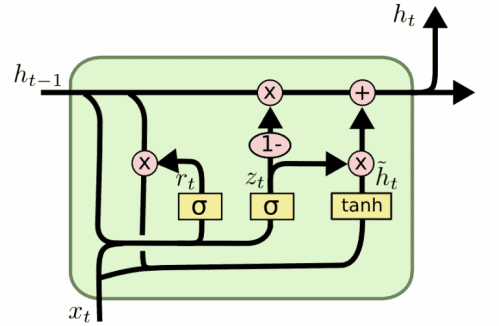

Рис. 7. Схема ячейки GRU

В GRU нет отдельной ячейки памяти, как в LSTM. Вместо этого, она обновляет скрытое состояние напрямую. Вентили обновления помогают модели решить, какая часть предыдущего скрытого состояния должна быть сохранена. Это делается путем комбинирования прошлого состояния и новой информации.

Вентиль сброса определяет, какая часть прошлого состояния важна для текущего ввода, а вентиль обновления использует эту информацию для формирования нового скрытого состояния. Это позволяет GRU более гибко регулировать поток информации.

GRU выполняет серию математических операций для обновления своего состояния, включая использование сигмоидной функции для вентиля и гиперболического тангенса для создания новых кандидатов на состояние. Эти операции помогают GRU динамически регулировать поток информации.

### Сравнение GRU с LSTM

1. Количество вентилей:
LSTM: Имеет три типа вентилей – вентиль забывания (forget gates), вентиль ввода (input gates) и вентиль вывода (output gates).
GRU: Имеет два типа вентилей – вентиль обновления (update gates) и вентиль сброса (reset gates).

2. Состояние ячейки:
LSTM: Включает в себя отдельное состояние ячейки и скрытое состояние, что обеспечивает дополнительный контроль над потоком информации.
GRU: Использует только скрытое состояние, что упрощает ее структуру.

3. Управление информацией:
LSTM: Вентиль забывания и вентиль ввода независимо контролируют поток информации, что позволяет более точно регулировать, какая информация сохраняется или отбрасывается.
GRU: Вентиль обновления одновременно контролирует информацию, которая сохраняется из прошлого состояния, и добавляемую новую информацию, что приводит к более глобальной регуляции.

### Когда применять?

В общем случае, не используйте SimpleRNN, всегда используйте модули LSTM или GRU.

**Как выбрать между LSTM или GRU?**

Эмпирического правила нет: часто это зависит от задачи, поэтому попробуйте оба варианта и используйте наиболее производительный вариант. Варианты применения слоев внутри архитектур НС мы подробнее рассмотрим в следующем колабе и сравним их.

Если важна скорость обучения и доступные вычислительные ресурсы ограничены, GRU может быть предпочтительнее из-за своей более простой структуры и меньшего количества параметров по сравнению с LSTM.

Для более простых или меньших наборов данных GRU может быть достаточной, поскольку она может достаточно эффективно обучаться на таких данных, не теряя в производительности.

Если задача требует более детального управления информацией и долгосрочной памяти (например, в сложных задачах обработки естественного языка с длинными зависимостями), LSTM может быть более подходящим выбором благодаря своей дополнительной сложности и дополнительному контролю над информацией.

## Двунаправленные рекурентные сети

Двунаправленная рекуррентная сеть (bidirectional RNN) — распространенная разновидность рекуррентных сетей, способная обеспечить более высокое качество решения некоторых задач. Она часто используется в обработке естественного языка — ее можно даже назвать швейцарским армейским ножом глубокого обучения для обработки естественного языка.

Рекуррентные сети зависят от порядка или от времени: они обрабатывают входные
последовательности по порядку, и любое изменение порядка следования данных
может полностью изменить представление, которое рекуррентная сеть извлечет
из последовательности. Именно поэтому они так хорошо справляются с задачами,
в которых порядок имеет значение, такими как задача прогнозирования температуры.

Двунаправленная рекуррентная сеть использует чувствительность RNN к порядку. Она состоит из двух обычных рекуррентных сетей, таких как слои GRU или LSTM. Каждая из этих сетей обрабатывает входную последовательность, одна в прямом направлении, другая - в обратном. Затем полученные представления объединяются, как показано на рис. 8.

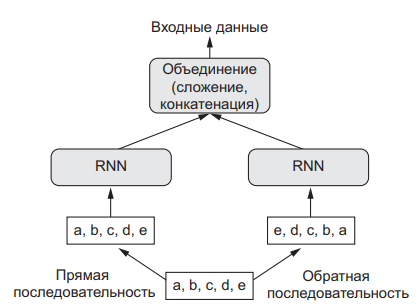

Рис. 8. Принцип действия двунаправленной рекуррентной нейронной сети

Обрабатывая последовательность в двух направлениях, двунаправленная рекуррентная сеть способна выявить шаблоны, незаметные для однонаправленной сети.

Для создания двунаправленной рекуррентной сети в Keras имеется слой `Bidirectional`, который в своем первом аргументе принимает экземпляр рекуррентного слоя. Слой `Bidirectional` создает второй, отдельный экземпляр этого рекуррентного слоя и использует один экземпляр для обработки входных последовательностей в прямом порядке, а другой — в обратном. В следующем колабе мы рассмотрим применение слоя на реальной задаче.


В следующем Блокноте мы продолжим знакомиться с нейронными сетями, которые используются для обработки последовательностей, а именно, [одномерными сверточными нейронными сетями](https://colab.research.google.com/drive/1SCmcJdfsaxpJiQz_SOMH6gixV-43zPIB).